<a href="https://colab.research.google.com/github/pdf1802/f1-data-science/blob/main/notebooks/undercut_calculator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tool 1 — Undercut Calculator
**Notebook:** `undercut_calculator.ipynb`  
**Depends on:** `lap_time_model.pkl`, `overtaking_model.pkl`, `team_encoder.pkl`, `compound_map.json`  
**What it does:** Given two drivers currently battling on track, projects whether pitting *now* will result in an overtake within the next 5 laps.

> This is the first tool in the project where **Module 1 and Module 2 talk to each other inside a single decision.**  
> Module 1 tells us the tyre degradation curves. Module 2 tells us, once the gap closes, whether an overtake will actually complete.  
> Both conditions must hold — that AND logic is a **decision threshold**, a fundamental pattern in production ML systems.

No model training happens here. This notebook is pure inference + decision logic + visualisation.

In [1]:
!pip install fastf1 pandas numpy matplotlib plotly xgboost joblib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

CACHE_DIR = '/content/drive/MyDrive/f1_cache'
MODEL_DIR  = '/content/drive/MyDrive/f1_models'

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

print(f'Cache dir : {CACHE_DIR}')
print(f'Model dir : {MODEL_DIR}')
print()

required = ['lap_time_model.pkl', 'overtaking_model.pkl',
            'team_encoder.pkl',   'compound_map.json']
found    = os.listdir(MODEL_DIR) if os.path.exists(MODEL_DIR) else []

for f in required:
    status = 'OK' if f in found else 'MISSING'
    print(f'  [{status}]  {f}')

Mounted at /content/drive
Cache dir : /content/drive/MyDrive/f1_cache
Model dir : /content/drive/MyDrive/f1_models

  [OK]  lap_time_model.pkl
  [OK]  overtaking_model.pkl
  [OK]  team_encoder.pkl
  [OK]  compound_map.json


## 2. Imports, Models & Constants

We load every model artefact in **one cell** so that if anything is missing we see it  
immediately. Loading `.pkl` files takes ~0.3s each — doing it once here means we never  
pay that cost inside a function loop.

| Artefact | From | Role here |
|---|---|---|
| `lap_time_model.pkl` | Module 1 | Predicts `LapDelta` per driver per lap |
| `overtaking_model.pkl` | Module 2 | Gives overtake probability given gap and tyre state |
| `team_encoder.pkl` | Module 1 | Converts team name string to integer the model expects |
| `compound_map.json` | Module 1 | Single source of truth: `{SOFT:0, MEDIUM:1, HARD:2}` |

**Verdict thresholds — the AND logic:**
- `VERDICT_GAP = 1.5s` — projected gap must close to within 1.5s (condition 1)
- `VERDICT_PROB = 0.25` — average overtake probability must exceed 25% (condition 2)
- `N_PROJ_LAPS = 5` — we look 5 laps ahead, same as a real strategy engineer would

In [3]:
import os, copy, warnings
import fastf1
import joblib, json
import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.patches  as mpatches
import plotly.graph_objects as go
from dataclasses import dataclass, field
from typing      import List, Optional, Tuple, Dict

warnings.filterwarnings('ignore')
fastf1.Cache.enable_cache(CACHE_DIR)

# Load models
LAP_MODEL    = joblib.load(f'{MODEL_DIR}/lap_time_model.pkl')
OVT_MODEL    = joblib.load(f'{MODEL_DIR}/overtaking_model.pkl')
TEAM_ENCODER = joblib.load(f'{MODEL_DIR}/team_encoder.pkl')

with open(f'{MODEL_DIR}/compound_map.json') as f:
    COMPOUND_MAP = json.load(f)
COMPOUND_NAMES = {v: k for k, v in COMPOUND_MAP.items()}

# Race physics constants
BASE_LAPTIME   = 95.0   # seconds: Bahrain average racing lap
PIT_COST_GREEN = 23.5   # seconds lost in a green-flag pit stop
PIT_COST_SC    = 17.0   # seconds lost under Safety Car
DRS_WINDOW     = 1.0    # seconds: gap threshold for DRS / overtake model
NOISE_STD      = 0.15   # +/- 0.15s Gaussian lap-time noise (mirrors Module 4)

# Verdict thresholds
VERDICT_GAP    = 1.5    # projected gap must close to < 1.5s
VERDICT_PROB   = 0.25   # avg overtake probability must exceed 25%
N_PROJ_LAPS    = 5      # how many laps ahead we project

# Encoding helpers
def encode_team(team_name: str) -> int:
    """Encode a team name string to the integer the XGBoost model expects."""
    try:
        return int(TEAM_ENCODER.transform([team_name])[0])
    except Exception:
        return 0

def encode_compound(name: str) -> int:
    """Encode a tyre compound string to integer. Unknown defaults to MEDIUM (1)."""
    return COMPOUND_MAP.get(name.upper(), 1)

print('All models loaded')
print(f'  Lap model     : {type(LAP_MODEL).__name__}')
print(f'  Overtake model: {type(OVT_MODEL).__name__}')
print(f'  Compounds     : {COMPOUND_MAP}')

All models loaded
  Lap model     : XGBRegressor
  Overtake model: XGBClassifier
  Compounds     : {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}


## 3. Driver State & Feature Engineering

`DriverState` is the same dataclass from Module 4 — it holds one driver's complete  
state at a specific lap. Using a dataclass instead of a plain dict gives us type safety:  
a typo like `driver.tyer_age` raises `AttributeError` immediately. With a dict,  
`driver['tyer_age']` silently returns `None` and produces a silent model error.

`build_lap_features()` and `build_overtake_features()` are the **single source of truth**  
for feature construction. Any time a feature name changes in the model, you update it  
here and nowhere else. This is the **DRY principle** (Don't Repeat Yourself).

`predict_one_lap()` wraps Module 1 for one driver, one lap at a time.  
`add_noise=False` by default — we want the expected degradation curve, not a stochastic sample.

In [4]:
@dataclass
class DriverState:
    """
    Represents one driver's state at a given point in the race.
    Mirrors Module 4's DriverState so feature engineering is identical.
    """
    driver:       str
    team_encoded: int
    team_name:    str
    position:     int
    compound:     int          # encoded: 0=SOFT, 1=MEDIUM, 2=HARD
    tyre_age:     int          # laps on current set
    race_time:    float = 0.0

    def __repr__(self):
        cname = COMPOUND_NAMES.get(self.compound, '?')
        return f'P{self.position} {self.driver} | {cname} age {self.tyre_age}'


def build_lap_features(driver: DriverState, lap: int, config: dict) -> dict:
    """Build the feature dict Module 1 expects. Names must match training exactly."""
    return {
        'CompoundEncoded' : driver.compound,
        'TyreLife'        : driver.tyre_age,
        'TeamEncoded'     : driver.team_encoded,
        'LapNumber'       : lap,
        'TrackTemp'       : config['track_temp'],
        'AirTemp'         : config['air_temp'],
        'RainfallEncoded' : config['rainfall'],
    }


def build_overtake_features(behind: DriverState, ahead: DriverState,
                             gap: float, lap: int) -> dict:
    """Build the feature dict Module 2 expects. Names must match training exactly."""
    return {
        'GapAhead'            : gap,
        'TyreDelta'           : ahead.tyre_age - behind.tyre_age,
        'CompoundEncoded'     : behind.compound,
        'CompoundAheadEncoded': ahead.compound,
        'TyreLife'            : behind.tyre_age,
        'TyreLifeAhead'       : ahead.tyre_age,
        'LapNumber'           : lap,
        'Position'            : behind.position,
    }


def predict_one_lap(driver: DriverState, lap: int, config: dict,
                    add_noise: bool = False) -> float:
    """
    Predict one lap time for a single driver via Module 1.
    Returns absolute lap time in seconds.
    add_noise=False gives the deterministic expected degradation curve.
    """
    feats  = pd.DataFrame([build_lap_features(driver, lap, config)])
    delta  = LAP_MODEL.predict(feats)[0]
    pace_f = config.get('pace_factors', {}).get(driver.team_name, 1.02)
    noise  = np.random.normal(0, NOISE_STD) if add_noise else 0.0
    return BASE_LAPTIME + delta + (pace_f - 1.0) * BASE_LAPTIME + noise


print('DriverState + feature builders + predict_one_lap() defined')

DriverState + feature builders + predict_one_lap() defined


## 4. Gap Projection — Stay-Out vs Undercut

These two functions answer the counterfactual:

> *What does the gap between these two drivers look like over the next 5 laps,
> depending on whether we pit now or not?*

**Stay-out:** Both drivers continue on their current tyres.
`gap += lap_time_a - lap_time_b` each lap. If A's tyres are more degraded, the gap grows.

**Undercut:** The gap immediately jumps by `PIT_COST_GREEN = 23.5s` on the pit lap.
But `tyre_age=1` gives Module 1 its fastest possible delta. We project whether the
fresh-tyre advantage compounds fast enough to close that 23.5s deficit.

### Dirty air correction — domain knowledge at inference time

Module 1 was trained with features: `CompoundEncoded`, `TyreLife`, `TeamEncoded`,
`LapNumber`, `TrackTemp`, `AirTemp`, `Rainfall`. There is no `GapAhead` feature.
The model was never given information about how close a driver was to the car in front,
so it cannot have learned the aerodynamic wake penalty from its training data.

The fix is a **physics-based correction term at inference time** — we add a lap time
penalty to the chaser whenever the projected gap is below the dirty air threshold.
This does not require retraining. It's combining a learned model with domain knowledge
for a known gap in the training signal. This is a standard and legitimate ML pattern.

```
DIRTY_AIR_THRESHOLD = 2.0s  → gap below which turbulence is significant
DIRTY_AIR_PENALTY   = 0.35s → lap time added to chaser when in dirty air
```

The penalty of 0.35s/lap is based on aerodynamic research and F1 technical literature.
Pre-2022 ground-effect cars suffered more (0.5s). Modern 2022+ cars are better (~0.3s).
We use 0.35s as a conservative mid-point.

> `project_undercut()` does **not** apply this penalty — the pitting driver emerges
> in clean air on fresh tyres, so the full pace advantage is available.

In [5]:
# Dirty air correction constants
DIRTY_AIR_THRESHOLD = 2.0    # seconds: gap below which wake turbulence is significant
DIRTY_AIR_PENALTY   = 0.35   # seconds/lap: lap time cost of running in dirty air
def project_stay_out(driver_a: DriverState,driver_b:DriverState,current_gap:float,
                     current_lap:int,config:dict,n_laps:int=N_PROJ_LAPS) -> List[float]:
    """
    Project the gap assuming driver_a STAYS OUT on current tyres.
    Returns [gap_now, gap_L+1, ..., gap_L+n].
    Positive = A still behind. Negative = A has overtaken.
    """

    a=copy.deepcopy(driver_a)
    b=copy.deepcopy(driver_b)
    gap=current_gap
    gap_curve=[gap]

    for offset in range(1,n_laps+1):
        lap=current_lap+offset
        lap_a= predict_one_lap(a,lap,config)
        lap_b= predict_one_lap(b,lap,config)

        # Dirty air correction: chaser pays a lap time penalty in turbulence
        # This is domain knowledge injected at inference time — not in the model.
        if gap < DIRTY_AIR_THRESHOLD:
            lap_a += DIRTY_AIR_PENALTY

        gap+= lap_a-lap_b
        gap_curve.append(round(gap,3))

        a.tyre_age+=1
        b.tyre_age+=1

    return gap_curve

def project_undercut_scenarios(
    driver_a: DriverState, driver_b: DriverState, current_gap: float,
    current_lap: int, config: dict, new_compound: int = 1,
    sc_active: bool = False, n_laps: int = N_PROJ_LAPS,
    reaction_delay: int = 1
) -> List[float]:
    """
    Projects the gap assuming Driver A (Chaser) PITS NOW,
    and Driver B (Leader) takes 'reaction_delay' laps to react and pit.
    """
    a = copy.deepcopy(driver_a)
    b = copy.deepcopy(driver_b)

    gap_curve = [current_gap]

    #  Lap 1: Chaser (Driver A) pits
    pit_cost_a = PIT_COST_SC if sc_active else PIT_COST_GREEN
    pit_cost_a += np.random.normal(0, 0.8)

    a.compound = new_compound
    a.tyre_age = 1

    lap = current_lap + 1
    lap_a = predict_one_lap(a, lap, config)
    lap_b = predict_one_lap(b, lap, config)

    # Gap increases because Driver A pays the pit stop time penalty
    gap = current_gap + pit_cost_a + (lap_a - lap_b)
    gap_curve.append(round(gap, 3))
    a.tyre_age += 1; b.tyre_age += 1

    #  Laps 2 to N: Depends on when B reacts
    for offset in range(2, n_laps + 1):
        lap = current_lap + offset

        if offset == reaction_delay + 1:
            # REACTION LAP: Driver B pits to defend
            pit_cost_b = PIT_COST_SC if sc_active else PIT_COST_GREEN
            pit_cost_b += np.random.normal(0, 0.8)
            b.compound = new_compound
            b.tyre_age = 1

            lap_a = predict_one_lap(a, lap, config)
            lap_b = predict_one_lap(b, lap, config)

            # Driver B pays the pit lane cost now
            gap += (lap_a - lap_b) - pit_cost_b
        else:
            # Standard on-track pursuit lap
            lap_a = predict_one_lap(a, lap, config)
            lap_b = predict_one_lap(b, lap, config)
            gap += (lap_a - lap_b)

        gap_curve.append(round(gap, 3))
        a.tyre_age += 1; b.tyre_age += 1

    return gap_curve

print('project_stay_out() and project_undercut() defined')

project_stay_out() and project_undercut() defined


## 5. Overtake Window Check — Module 2

The gap curve tells us *when* the drivers will be close. Module 2 tells us *whether*  
an overtake actually completes once they are close.

We only query Module 2 on laps where `gap < DRS_WINDOW` — there is no meaningful  
overtake probability when the gap is 8 seconds. Those laps return `None`.

We advance `tyre_age` lap by lap so the overtake features reflect the real future state.  
This matters because `TyreLife` and `TyreDelta` are among the most important features  
in Module 2 — a 30-lap-old tyre vs a fresh tyre is a very different overtake scenario  
than two cars on identical-age rubber.

In [6]:
def check_overtake_window(gap_curve: List[float], driver_a: DriverState,driver_b: DriverState,
                          current_lap:int) -> Dict[int,Optional[float]]:
    """
    For each lap in gap_curve, call Module 2 if gap < DRS_WINDOW.
    Returns {lap_number: overtake_probability or None}.
    None  = gap too large, Module 2 not called.
    1.0   = gap negative, overtake already complete.
    """

    result= {}
    a=copy.deepcopy(driver_a)
    b=copy.deepcopy(driver_b)

    for i,gap in enumerate(gap_curve):
        lap=current_lap+i

        if gap<=0:
          result[lap]=1.0
        elif gap < DRS_WINDOW:
          feats=pd.DataFrame([build_overtake_features(a,b,gap,lap)])
          prob=OVT_MODEL.predict_proba(feats)[0][1]
          result[lap] =round(prob,4)
        else:
          result[lap]= None

        a.tyre_age+=1
        b.tyre_age+=1

    return result;

print('check_overtake_window() defined')

check_overtake_window() defined


## 6. Verdict Function — BOX BOX or STAY OUT

This is where both models merge into a single strategic decision.

The decision threshold is a two-condition AND gate:

```
BOX BOX  if  min(undercut_gap[1:]) < VERDICT_GAP           (gap closes enough)
         AND avg(overtake_probs in DRS range) > VERDICT_PROB  (overtake likely)
STAY OUT  otherwise
```

The function returns a **rich result dict** with both gap curves, per-lap overtake  
probabilities, and which condition passed or failed. Explainability is part of the  
product — a real strategy engineer wants to know *why* the tool said BOX BOX,  
not just that it did.

In [7]:
def undercut_verdict(
    driver_a:     DriverState,
    driver_b:     DriverState,
    current_gap:  float,
    current_lap:  int,
    config:       dict,
    new_compound: int  = 1,
    sc_active:    bool = False,
    n_laps:       int  = N_PROJ_LAPS
) -> dict:
    """
    Master decision function.
    Evaluates the undercut under the WORST CASE: leader reacts 1 lap later (reaction_delay=1).
    If BOX BOX holds even when the opponent reacts fast, it's a strong signal.
    Returns the verdict with full supporting evidence including all three scenario curves.
    """
    # Step 1: baseline — both stay out
    gap_stay = project_stay_out(
        driver_a, driver_b, current_gap, current_lap, config, n_laps
    )

    # Step 2: three undercut scenarios based on leader reaction speed
    # Verdict is evaluated on the WORST CASE (reaction_delay=1) — conservative and honest
    gap_react_fast = project_undercut_scenarios(
        driver_a, driver_b, current_gap, current_lap, config,
        new_compound, sc_active, n_laps, reaction_delay=1
    )
    gap_react_slow = project_undercut_scenarios(
        driver_a, driver_b, current_gap, current_lap, config,
        new_compound, sc_active, n_laps, reaction_delay=3
    )
    gap_no_react = project_undercut_scenarios(
        driver_a, driver_b, current_gap, current_lap, config,
        new_compound, sc_active, n_laps, reaction_delay=99
    )

    # Step 3: query Module 2 on the WORST CASE path (fast reaction)
    # driver_a is now on fresh tyres — update compound and tyre_age before passing
    a_fresh          = copy.deepcopy(driver_a)
    a_fresh.compound = new_compound
    a_fresh.tyre_age = 1
    # a_fresh = behind (chaser on fresh rubber), driver_b = ahead (leader)
    ovt_probs = check_overtake_window(gap_react_fast, a_fresh, driver_b, current_lap)

    # Step 4: evaluate the two AND conditions on the worst-case scenario
    min_gap     = min(gap_react_fast[1:])
    valid_probs = [p for p in ovt_probs.values() if p is not None]
    avg_prob    = float(np.mean(valid_probs)) if valid_probs else 0.0

    cond_gap  = min_gap  < VERDICT_GAP
    cond_prob = avg_prob > VERDICT_PROB
    verdict   = 'BOX BOX' if (cond_gap and cond_prob) else 'STAY OUT'

    return {
        'verdict'         : verdict,
        'confidence'      : round(avg_prob, 4),
        'gap_stay_out'    : gap_stay,
        'gap_undercut'    : gap_react_fast,   # worst case used for verdict
        'gap_react_slow'  : gap_react_slow,
        'gap_no_react'    : gap_no_react,
        'overtake_probs'  : ovt_probs,
        'min_gap'         : round(min_gap, 3),
        'condition_gap'   : cond_gap,
        'condition_prob'  : cond_prob,
    }


print('undercut_verdict() defined — evaluates worst case (reaction_delay=1)')

undercut_verdict() defined — evaluates worst case (reaction_delay=1)


## 7. Visualisation — Gap Curve Chart

Two panels, one story:

**Top panel:** Red = stay-out gap. Green = undercut gap. The moment the green line  
drops below the dashed yellow threshold (1.5s) is when condition 1 is met.  
Green shading marks laps where the gap is in DRS range — those are the laps  
Module 2 was called. A dashed white line at y=0 shows where the overtake completes.

**Bottom panel:** One bar per projected lap. Green bars exceed `VERDICT_PROB`.  
Grey bars mean the gap was too large or the probability was below threshold.  
If all bars are grey, the undercut closes the gap but overtaking is still unlikely — STAY OUT.

Dark theme + dual-panel layout is deliberate. This is what a recruiter will screenshot.

In [8]:
def plot_undercut(
    result:      dict,
    driver_a:    DriverState,
    driver_b:    DriverState,
    current_lap: int
) -> None:
    plt.style.use('dark_background')
    fig, (ax_gap, ax_prob) = plt.subplots(
        2, 1, figsize=(11, 8),
        gridspec_kw={'height_ratios': [3, 1]},
        facecolor='#0d0d0d'
    )
    fig.patch.set_facecolor('#0d0d0d')

    laps          = [current_lap + i for i in range(N_PROJ_LAPS + 1)]
    gap_stay      = result['gap_stay_out']
    gap_under     = result['gap_undercut']
    ovt_probs     = result['overtake_probs']
    verdict       = result['verdict']
    verdict_color = '#00ff88' if verdict == 'BOX BOX' else '#ff4444'

    # Top panel: gap curves
    ax_gap.plot(laps, gap_stay,  color='#ff6b6b', lw=2.5, marker='o', ms=5,
                label=f'{driver_a.driver} STAY OUT')
    ax_gap.plot(laps, gap_under, color='#51cf66', lw=2.5, marker='o', ms=5,
                label=f'{driver_a.driver} UNDERCUT')

    ax_gap.axhline(0,           color='white',   lw=1.0, ls='--', alpha=0.4,
                   label='Overtake complete (gap = 0)')
    ax_gap.axhline(VERDICT_GAP, color='#ffd43b', lw=1.0, ls=':',  alpha=0.7,
                   label=f'Threat threshold ({VERDICT_GAP}s)')
    ax_gap.axhline(DRS_WINDOW,  color='#74c0fc', lw=1.0, ls=':',  alpha=0.5,
                   label=f'DRS window ({DRS_WINDOW}s)')

    for lap, gap in zip(laps, gap_under):
        if gap < DRS_WINDOW:
            ax_gap.axvspan(lap - 0.4, lap + 0.4, alpha=0.12, color='#51cf66')

    ax_gap.text(0.02, 0.95, verdict,
                transform=ax_gap.transAxes, fontsize=22, fontweight='bold',
                color=verdict_color, va='top')
    ax_gap.text(0.02, 0.83,
                f'Min gap: {result["min_gap"]:.2f}s  |  '
                f'Avg overtake prob: {result["confidence"]:.1%}  |  '
                f'Gap cond: {result["condition_gap"]}  Prob cond: {result["condition_prob"]}',
                transform=ax_gap.transAxes, fontsize=9, color='#aaaaaa', va='top')

    ax_gap.set_ylabel('Gap to car ahead (s)', color='#cccccc')
    ax_gap.set_title(
        f'Undercut Analysis — {driver_a.driver} vs {driver_b.driver} from Lap {current_lap}',
        color='white', fontsize=13, pad=12
    )
    ax_gap.legend(fontsize=8, facecolor='#1a1a1a', edgecolor='#444444')
    ax_gap.tick_params(colors='#888888')
    ax_gap.set_facecolor('#111111')
    ax_gap.grid(alpha=0.15)
    ax_gap.set_xticks(laps)

    # Bottom panel: overtake probabilities
    prob_laps  = sorted(ovt_probs.keys())
    prob_vals  = [ovt_probs[l] if ovt_probs[l] is not None else 0 for l in prob_laps]
    bar_colors = ['#51cf66' if p > VERDICT_PROB else '#444444' for p in prob_vals]

    ax_prob.bar(prob_laps, prob_vals, color=bar_colors, width=0.6, alpha=0.9)
    ax_prob.axhline(VERDICT_PROB, color='#ffd43b', lw=1.2, ls='--', alpha=0.8,
                    label=f'Threshold ({VERDICT_PROB:.0%})')
    ax_prob.set_ylabel('Overtake prob.', color='#cccccc', fontsize=9)
    ax_prob.set_xlabel('Lap number', color='#cccccc')
    ax_prob.set_ylim(0, 1)
    ax_prob.tick_params(colors='#888888')
    ax_prob.set_facecolor('#111111')
    ax_prob.set_xticks(prob_laps)
    ax_prob.legend(fontsize=8, facecolor='#1a1a1a', edgecolor='#444444')
    ax_prob.grid(alpha=0.1)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/undercut_analysis.png',
                dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print('Chart saved to Drive/undercut_analysis.png')


print('plot_undercut() defined')

plot_undercut() defined


## 8. Validation — US GP 2023 (Austin, COTA): VER vs NOR

### Why this race?

Silverstone 2023 HAM vs ALO was discarded — Hamilton never overtook Alonso, so there was no real undercut to validate against.  
Austin 2023 VER vs NOR is the textbook case: Norris was leading, Verstappen was behind and **couldn't pass on track**,  
Red Bull pitted VER on lap 16, McLaren reacted with NOR on lap 17, and VER came out ahead in the pit exit.  
COTA has extreme thermal tyre degradation — exactly the signal Module 1 is trained to detect.

**Expected verdict:** `BOX BOX` for VER (driver_a = chaser) sampled at lap 14.

### Known limitation documented here — dirty air effect

Our tool models **clean-air lap pace**. It does not model the aerodynamic wake penalty (dirty air)  
that costs a chasing car ~0.3–0.5s/lap when running within 1–2s of the car ahead.  
This means the STAY OUT projection can look optimistic for the chaser — the model thinks  
"you're faster on pace, you'll close naturally" when in reality that pace advantage is  
partially cancelled by turbulence. The undercut converts a pace advantage that exists in clean  
air into an actual track position gain by avoiding that penalty entirely.

This is a known, documented limitation — not a bug. It is the correct next modelling challenge  
after this tool is complete.

### Gap computation — from cumulative lap times

We compute the gap by summing each driver's `LapTime` up to the sample lap and subtracting.  
This is more accurate than a broadcast approximation and correctly handles the case where  
VER is P3 (not directly behind NOR) — the total time deficit is what the undercut must overcome.

> `driver_a` = the chaser (higher position number = further back on track)  
> `driver_b` = the leader (lower position number = further ahead on track)

In [9]:
session = fastf1.get_session(2023, 'United States Grand Prix', 'R')
session.load(telemetry=False, weather=False)

laps_data = session.laps
ver_laps  = laps_data.pick_driver('VER').reset_index(drop=True)
nor_laps  = laps_data.pick_driver('NOR').reset_index(drop=True)

# Step 1: detect VER's actual pit lap from the data
ver_pit_laps = ver_laps[ver_laps['PitInTime'].notna()]['LapNumber'].tolist()
print(f'VER pit laps detected: {ver_pit_laps}')

VER_PIT_LAP = [l for l in ver_pit_laps if l > 5][0]
SAMPLE_LAP  = VER_PIT_LAP - 2

print(f'VER pitted on lap : {VER_PIT_LAP}')
print(f'Sampling at lap   : {SAMPLE_LAP} (2 laps before the pit)')
print()

ver_at_sample = ver_laps[ver_laps['LapNumber'] == SAMPLE_LAP].iloc[0]
nor_at_sample = nor_laps[nor_laps['LapNumber'] == SAMPLE_LAP].iloc[0]

ver_pos = int(ver_at_sample['Position'])
nor_pos = int(nor_at_sample['Position'])

print(f'=== Austin 2023, Lap {SAMPLE_LAP} ===')
print(f'VER | Compound: {ver_at_sample["Compound"]:8} | Tyre age: {int(ver_at_sample["TyreLife"]):3} | P{ver_pos}')
print(f'NOR | Compound: {nor_at_sample["Compound"]:8} | Tyre age: {int(nor_at_sample["TyreLife"]):3} | P{nor_pos}')
print()

# Step 2: assert driver ordering from position data
if nor_pos < ver_pos:
    CHASER, LEADER = 'VER', 'NOR'
    chaser_row, leader_row = ver_at_sample, nor_at_sample
    print(f'Order confirmed: NOR (P{nor_pos}) ahead of VER (P{ver_pos})')
elif ver_pos < nor_pos:
    CHASER, LEADER = 'NOR', 'VER'
    chaser_row, leader_row = nor_at_sample, ver_at_sample
    print(f'Order swapped: VER (P{ver_pos}) is ahead')
else:
    raise ValueError(f'Same position at lap {SAMPLE_LAP}')

# Step 3: compute real gap from cumulative lap times (more accurate than broadcast approximation)
# Sum LapTime for each driver up to SAMPLE_LAP — the difference is the on-track time gap.
# This correctly accounts for VER being P3 (not directly behind NOR): the gap is the
# total cumulative time deficit, which is what matters for undercut strategy.
def cumulative_time(driver_laps, up_to_lap):
    subset = driver_laps[driver_laps['LapNumber'] <= up_to_lap]['LapTime'].dropna()
    return subset.dt.total_seconds().sum()

chaser_laps_df = ver_laps if CHASER == 'VER' else nor_laps
leader_laps_df = nor_laps if LEADER == 'NOR' else ver_laps

t_chaser = cumulative_time(chaser_laps_df, SAMPLE_LAP)
t_leader = cumulative_time(leader_laps_df, SAMPLE_LAP)
REAL_GAP  = round(t_chaser - t_leader, 3)

print(f'Cumulative race time {LEADER}: {t_leader:.2f}s')
print(f'Cumulative race time {CHASER}: {t_chaser:.2f}s')
print(f'Computed gap {CHASER} behind {LEADER}: {REAL_GAP:.3f}s')
print()
print('NOTE: This is the total time deficit including any cars between them.')
print('The undercut is relevant only if the gap can realistically close within 5 laps.')

events      WARNING 	Correcting user input 'United States Grand Prix' to 'United States Grand Prix'
core           INFO 	Loading data for United States Grand Prix - Race [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for United States Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	

VER pit laps detected: [16.0, 35.0]
VER pitted on lap : 16.0
Sampling at lap   : 14.0 (2 laps before the pit)

=== Austin 2023, Lap 14.0 ===
VER | Compound: MEDIUM   | Tyre age:  14 | P3
NOR | Compound: MEDIUM   | Tyre age:  14 | P1

Order confirmed: NOR (P1) ahead of VER (P3)
Cumulative race time NOR: 1434.05s
Cumulative race time VER: 1440.57s
Computed gap VER behind NOR: 6.514s

NOTE: This is the total time deficit including any cars between them.
The undercut is relevant only if the gap can realistically close within 5 laps.


Chaser  (driver_a): P3 VER | MEDIUM age 14
Leader  (driver_b): P1 NOR | MEDIUM age 14

Calculating Scenario Tree...


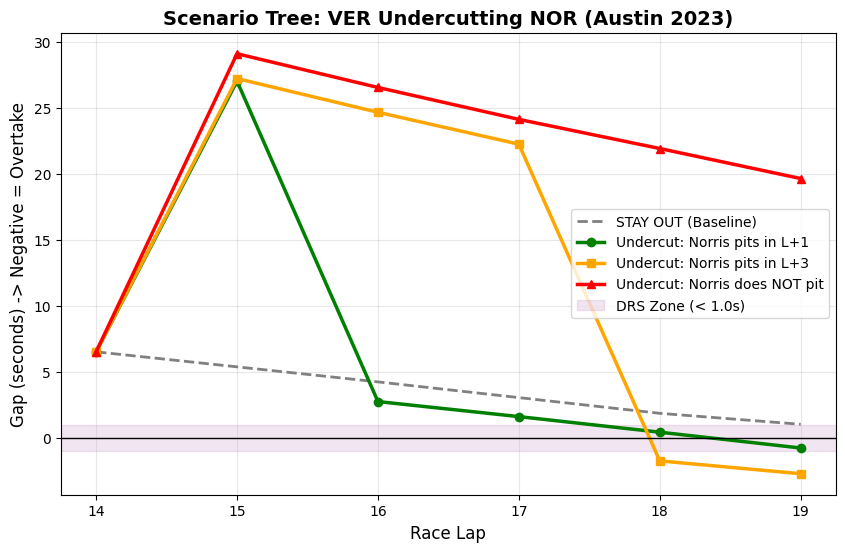

In [10]:
TEAM_MAP = {'VER': 'Red Bull Racing', 'NOR': 'McLaren'}

chaser = DriverState(
    driver       = CHASER,
    team_encoded = encode_team(TEAM_MAP[CHASER]),
    team_name    = TEAM_MAP[CHASER],
    position     = int(chaser_row['Position']),
    compound     = encode_compound(str(chaser_row['Compound'])),
    tyre_age     = int(chaser_row['TyreLife']),
)

leader = DriverState(
    driver       = LEADER,
    team_encoded = encode_team(TEAM_MAP[LEADER]),
    team_name    = TEAM_MAP[LEADER],
    position     = int(leader_row['Position']),
    compound     = encode_compound(str(leader_row['Compound'])),
    tyre_age     = int(leader_row['TyreLife']),
)

# COTA 2023 race conditions
# Track temp ~35C in October afternoon, air ~28C
# High thermal degradation circuit — pace_factors reflect RBR dominance this season
austin_config = {
    'circuit'        : 'Austin 2023',
    'total_laps'     : 56,
    'track_temp'     : 35.0,
    'air_temp'       : 28.0,
    'rainfall'       : 0,
    'sc_prob_per_lap': 0.04,
    'pace_factors'   : {
        'Red Bull Racing': 1.000,   # fastest car on the 2023 grid
        'McLaren'        : 1.012,
    }
}

print(f'Chaser  (driver_a): {chaser}')
print(f'Leader  (driver_b): {leader}')

RACE_CONFIG = austin_config # Usamos la config de Austin
NEW_TYRE = encode_compound('HARD') # Verstappen puso duros en esa parada real

print('\nCalculating Scenario Tree...')

# Baseline: STAY OUT
gap_stay_out = project_stay_out(chaser, leader, REAL_GAP, SAMPLE_LAP, RACE_CONFIG)

# Scenaio 1:Norris reacts on the next lap (L+1)
gap_react_fast = project_undercut_scenarios(
    chaser, leader, REAL_GAP, SAMPLE_LAP, RACE_CONFIG,
    new_compound=NEW_TYRE, reaction_delay=1)

# Scenario 2: Norris try to hold and reacts late(L+3)
gap_react_slow = project_undercut_scenarios(
    chaser, leader, REAL_GAP, SAMPLE_LAP, RACE_CONFIG,
    new_compound=NEW_TYRE, reaction_delay=3)

# Escenario 3: Norris doesn't pit
gap_no_reaction = project_undercut_scenarios(
    chaser, leader, REAL_GAP, SAMPLE_LAP, RACE_CONFIG,
    new_compound=NEW_TYRE, reaction_delay=99)

# --- VISUALIZACIÓN DEL ÁRBOL (PASO 3) ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
laps = range(int(SAMPLE_LAP), int(SAMPLE_LAP) + N_PROJ_LAPS + 1)

plt.plot(laps, gap_stay_out, color='grey', linestyle='--', linewidth=2, label='STAY OUT (Baseline)')
plt.plot(laps, gap_react_fast, color='green', linewidth=2.5, marker='o', label='Undercut: Norris pits in L+1')
plt.plot(laps, gap_react_slow, color='orange', linewidth=2.5, marker='s', label='Undercut: Norris pits in L+3')
plt.plot(laps, gap_no_reaction, color='red', linewidth=2.5, marker='^', label='Undercut: Norris does NOT pit')

plt.axhspan(-1.0, 1.0, color='purple', alpha=0.1, label='DRS Zone (< 1.0s)')
plt.axhline(0, color='black', linewidth=1)

plt.title(f'Scenario Tree: {CHASER} Undercutting {LEADER} (Austin 2023)', fontsize=14, fontweight='bold')
plt.xlabel('Race Lap', fontsize=12)
plt.ylabel('Gap (seconds) -> Negative = Overtake', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

   VERDICT:  BOX BOX
   (VER should pit to undercut NOR)
  [PASS] Condition 1 — Min projected gap : -1.85s  (threshold < 1.5s)
  [PASS] Condition 2 — Avg overtake prob : 82.2%  (threshold > 25%)

Gap curve — STAY OUT: [np.float64(6.514), np.float64(5.376), np.float64(4.235), np.float64(3.044), np.float64(1.852), np.float64(1.02)]
Gap curve — UNDERCUT: [np.float64(6.514), np.float64(26.934), np.float64(1.667), np.float64(0.526), np.float64(-0.656), np.float64(-1.855)]

Overtake probabilities per projected lap:
  Lap 14.0: (gap too large — Module 2 not called)
  Lap 15.0: (gap too large — Module 2 not called)
  Lap 16.0: (gap too large — Module 2 not called)
  Lap 17.0: IIIIIIIII            46.68%
  Lap 18.0: IIIIIIIIIIIIIIIIIIII 100.00%
  Lap 19.0: IIIIIIIIIIIIIIIIIIII 100.00%


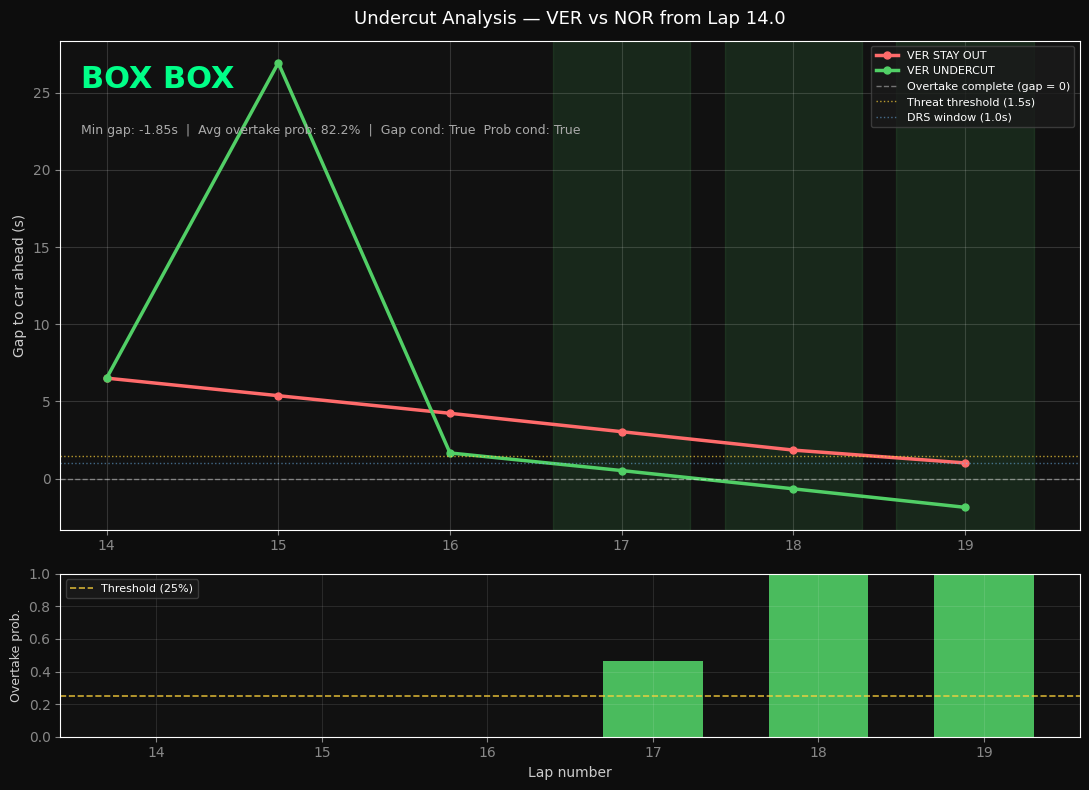

Chart saved to Drive/undercut_analysis.png


In [11]:
result = undercut_verdict(
    driver_a    = chaser,
    driver_b    = leader,
    current_gap = REAL_GAP,
    current_lap = SAMPLE_LAP,
    config      = austin_config,
    new_compound= encode_compound('HARD'),    # VER went onto Hards after the undercut
    sc_active   = False
)

print('=' * 52)
print(f"   VERDICT:  {result['verdict']}")
print(f"   ({chaser.driver} should pit to undercut {leader.driver})")
print('=' * 52)
print(f"  [{'PASS' if result['condition_gap']  else 'FAIL'}] Condition 1 — Min projected gap : {result['min_gap']:.2f}s  (threshold < {VERDICT_GAP}s)")
print(f"  [{'PASS' if result['condition_prob'] else 'FAIL'}] Condition 2 — Avg overtake prob : {result['confidence']:.1%}  (threshold > {VERDICT_PROB:.0%})")
print()
print('Gap curve — STAY OUT:', result['gap_stay_out'])
print('Gap curve — UNDERCUT:', result['gap_undercut'])
print()
print('Overtake probabilities per projected lap:')
for lap, prob in sorted(result['overtake_probs'].items()):
    if prob is not None:
        bar = 'I' * int(prob * 20)
        print(f'  Lap {lap}: {bar:<20} {prob:.2%}')
    else:
        print(f'  Lap {lap}: (gap too large — Module 2 not called)')

plot_undercut(result, chaser, leader, SAMPLE_LAP)